# Load Model and Data

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import torch 
from dreamerv4uwm.datasets import ShardedHDF5Dataset
from dreamerv4uwm.models.utils import load_tokenizer
from dreamerv4uwm.models.utils import load_denoiser
# DATA_PATH = "/home/mim-server/datasets/soar_data_sharded"
# DATA_PATH = "/home/mim-server/datasets/Finger/H5/combined"
DATA_PATH = "/home/mim-server/datasets/pushT/shareded-demo/"
# DATA_PATH = "/media/mim-server/Volume1/lewm/sharded/cube/"
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
resolution = (256, 256)

In [3]:
from hydra import initialize, compose
from omegaconf import OmegaConf
with initialize(version_base=None, config_path="../scripts/config"):
    cfg = compose(config_name="dynamics/pushT.yaml")
    # cfg = compose(config_name="dynamics/lewm-cubes.yaml")

/home/mim-server/miniconda3/envs/dreamerv4/lib/python3.11/site-packages/hydra/_internal/defaults_list.py:251: UserWarning: In 'dynamics/pushT.yaml': Defaults list is missing `_self_`. See https://hydra.cc/docs/1.2/upgrades/1.0_to_1.1/default_composition_order for more information
  warnings.warn(msg, UserWarning)


In [4]:
is_2x_temporal = True

if is_2x_temporal:
    cfg.denoiser.layer_types = ["spatial", "temporal", "spatial", "temporal"]
    dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/no-shortcuts/wm-policy-2x-temporal-293044.pt"
else:
    cfg.denoiser.layer_types = ["spatial", "spatial", "spatial", "temporal"]
    dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/no-shortcuts/wm-policy-1x-temporal-293044.pt"


In [5]:
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/no-shortcuts/all-2x-temporal-485204.pt"
dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/pushT/final/joint-model/v1/432360.pt"
# dynamics_ckpt = "/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/dynamics/lewm-cubes/joint/250000.pt"

In [6]:
tokenizer_ckpt="/home/mim-server/projects/rooholla/dreamerV4-UWM/checkpoints/tokenizer_ckpts/pushT.pt"
cfg.dynamics_ckpt = dynamics_ckpt
cfg.tokenizer_ckpt=tokenizer_ckpt
denoiser = load_denoiser(cfg, device, max_num_forward_steps=300)
tokenizer = load_tokenizer(cfg, device, max_num_forward_steps=300)
tokenizer = tokenizer.eval().cuda()
denoiser = denoiser.eval().cuda()

In [7]:
import mediapy
from torch.nn.functional import interpolate

dataset = ShardedHDF5Dataset(
        data_dir=DATA_PATH,
        window_size=64,
        stride=1,
        split='train',
        train_fraction=0.9,
        split_seed=123,
    )

# Arbitrary index into that episode
batch = dataset[torch.randint(len(dataset), (1,)).item()]
# imgs = batch["image"][:,[2, 1, 0], :, :]  # (T, C, H, W)
imgs = batch["image"]  # (T, C, H, W)
actions = batch["action"][:,:cfg.denoiser.n_actions]  # (1, T, N_lat, D_lat)
# actions=torch.zeros_like(actions)
imgs = interpolate(imgs, resolution).to(device=device)[None] # resize to tokenizer resolution

with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        latents = tokenizer.encode(imgs)
        imgs_recon = tokenizer.decode(latents)

from mediapy import show_video
def plotVideo(video):
    imgs = video.cpu().permute(0,2,3,1).to(torch.float32).numpy()*255
    imgs = imgs.astype('uint8')
    mediapy.show_video(imgs, fps=10)

plotVideo(imgs_recon[0])
plotVideo(imgs[0])

Train split: 4286 windows from 69 episodes


This browser does not support the video tag.


This browser does not support the video tag.


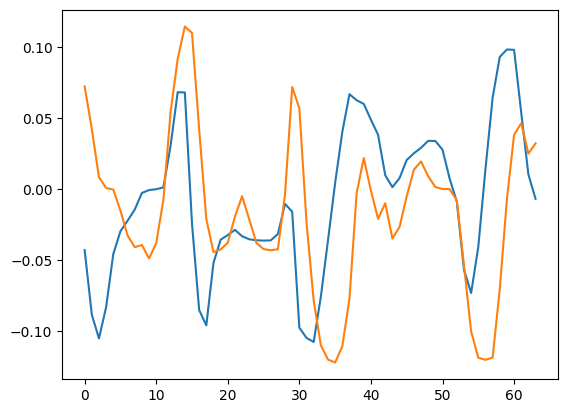

In [8]:
import matplotlib.pyplot as plt
# plot actions 
plt.plot(actions.cpu().numpy())

# Unified Sampler — All 5 UWM Modes

The `unified_flowmatching_sampler` supports all training modes:
- **wm** — World model: given context obs + all actions, predict future obs
- **policy** — Policy: given context obs + context actions, predict future obs + future actions
- **video** — Video prediction: given context obs only (no actions), predict future obs
- **id** — Inverse dynamics: given all obs (clean), predict actions
- **forcing** — Diffusion forcing: given context obs + context actions, predict future obs + future actions

In [9]:
from dreamerv4uwm.sampling import unified_flowmatching_sampler
import matplotlib.pyplot as plt

def plotSnapshots(video, n_frames=5, border_width=2, figsize=None):
    """Plot n_frames evenly-spaced snapshots from a video tensor, separated by black borders.
    
    Args:
        video: (T, C, H, W) tensor with values in [0, 1].
        n_frames: number of frames to sample.
        border_width: width of black separator lines in pixels.
    """
    import numpy as np
    T = video.shape[0]
    indices = np.linspace(0, T - 1, n_frames, dtype=int)
    frames = video[indices].cpu().permute(0, 2, 3, 1).to(torch.float32).numpy()  # (n, H, W, C)
    frames = np.clip(frames * 255, 0, 255).astype(np.uint8)
    H, W, C = frames.shape[1], frames.shape[2], frames.shape[3]
    border = np.zeros((H, border_width, C), dtype=np.uint8)
    parts = []
    for i, f in enumerate(frames):
        if i > 0:
            parts.append(border)
        parts.append(f)
    strip = np.concatenate(parts, axis=1)
    if figsize is None:
        figsize = (n_frames * 3, 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.imshow(strip)
    ax.axis('off')
    plt.tight_layout()
    plt.show()

def plotActions(actions, figsize=None):
    import numpy as np
    act = actions.cpu().float().numpy() if hasattr(actions, 'cpu') else np.array(actions)
    # if figsize is None:
    figsize = (3 , 3)
    fig, ax = plt.subplots(1, 1, figsize=figsize)
    ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.plot(act[:, 0], linewidth=3, label=r'$\mathbf{v_x}$')
    ax.plot(act[:, 1], linewidth=3, label=r'$\mathbf{v_y}$')
    ax.set_ylim(-1., 1.)
    ax.set_xticklabels([])
    ax.tick_params(axis='x', length=0)
    ax.tick_params(axis='y', labelsize=16)
    for label in ax.get_yticklabels():
        label.set_fontweight('bold')
    ax.legend(fontsize=16)
    plt.tight_layout()
    plt.show()

In [10]:
num_pred_steps = 16
num_diffusion_steps = 128
T_ctx = 24

latents_ctx = latents[:, :T_ctx, ...].clone()


## 1. World Model (`wm`)
Given context obs and **all** actions (context + future), predict future observations. Actions are treated as clean conditions throughout.

This browser does not support the video tag.


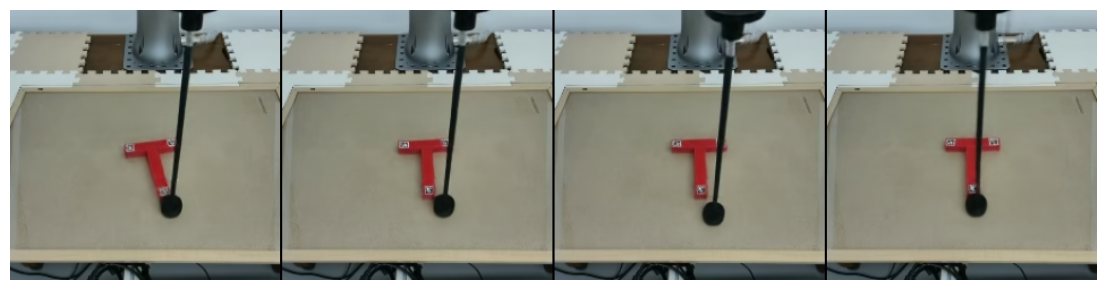

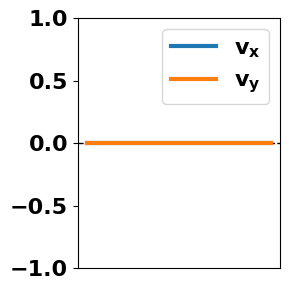

In [44]:
all_actions_wm = torch.zeros(1, T_ctx + num_pred_steps, 2).to('cuda')  # (1, T_total, n_act)
# all_actions_wm[:, T_ctx:, 0] =  0.  # zero out future actions for worldmodel sampling
# all_actions_wm[:, T_ctx:, 0] =  0.0
all_actions_wm[:, T_ctx:, :] =  0.0
all_actions_wm[:, T_ctx:, 0] =  0.0
all_actions_wm[:, T_ctx:, 1] =  0.0

# all_actions_wm = torch.from_numpy(pr_act_full)[None].clone()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_wm, _ = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='wm',
        all_actions=all_actions_wm,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
        context_cond_tau=0.8,
    )
    with torch.no_grad():
        img_pred_wm = tokenizer.decode(pred_obs_wm)

plotVideo(img_pred_wm[0].to(torch.float32))
plotSnapshots(img_pred_wm[0].to(torch.float32), n_frames=4)
plotActions(all_actions_wm[0, T_ctx:T_ctx+num_pred_steps])

## 2. Policy (`policy`)
Given context obs + context actions, jointly predict future observations **and** future actions.

This browser does not support the video tag.


This browser does not support the video tag.


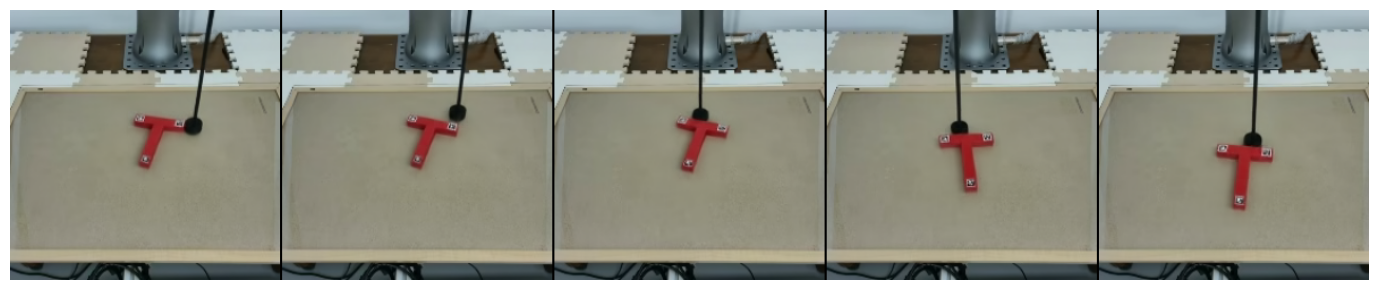

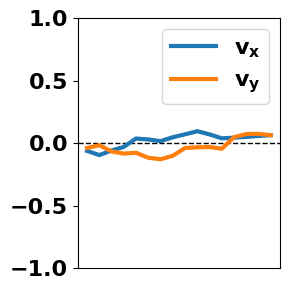

In [14]:
# T_ctx = 4
ctx_actions_policy = actions[:T_ctx][None].cuda()  # (1, T_ctx, n_act)
# ctx_actions_policy+=torch.randn_like(ctx_actions_policy)*0.1  # add noise to context actions for policy sampling

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol, pred_act_pol = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol = tokenizer.decode(pred_obs_pol)

plotVideo(img_pred_pol[0].to(torch.float32))
plotVideo(imgs[0,0:T_ctx].to(torch.float32))
plotSnapshots(img_pred_pol[0].to(torch.float32))
pr_act = pred_act_pol[0].cpu().float().numpy()
plotActions(pr_act)

## 3. Video Prediction (`video`)
Given context obs only (no action signal at all), predict future observations. Actions are pure noise throughout — the model must predict the future from visual context alone.

In [11]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_vid, _ = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='video',
        ctx_actions=ctx_actions_policy,  # only used to infer n_act dimension
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_vid = tokenizer.decode(pred_obs_vid)

plotVideo(img_pred_vid[0].to(torch.float32))
plotSnapshots(img_pred_vid[0].to(torch.float32))

NameError: name 'ctx_actions_policy' is not defined

## 4. Inverse Dynamics (`id`)
Given **all** observations (context + future, clean), predict actions for all frames. The model infers what actions produced the observed state transitions.

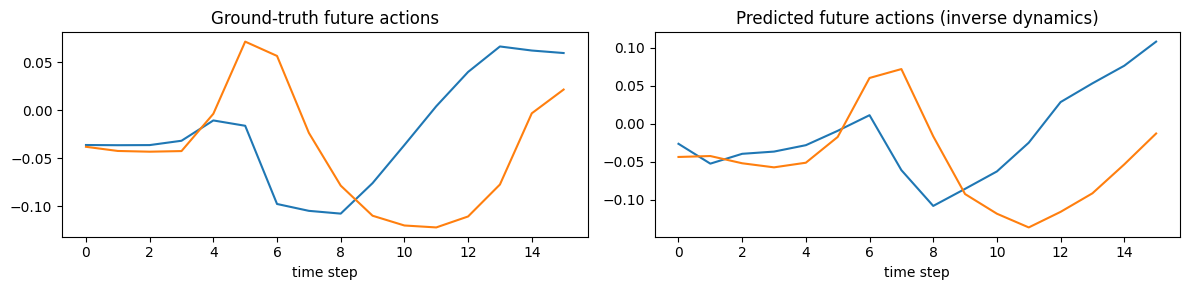

In [12]:
all_latents_id = latents[:, :T_ctx + num_pred_steps, ...]  # (1, T_total, N_lat, D_lat)

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    _, pred_act_id = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='id',
        ctx_actions=ctx_actions_policy,  # used to infer n_act
        all_latents=all_latents_id,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )

# Plot predicted vs ground-truth actions (future portion only)
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_id[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (inverse dynamics)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

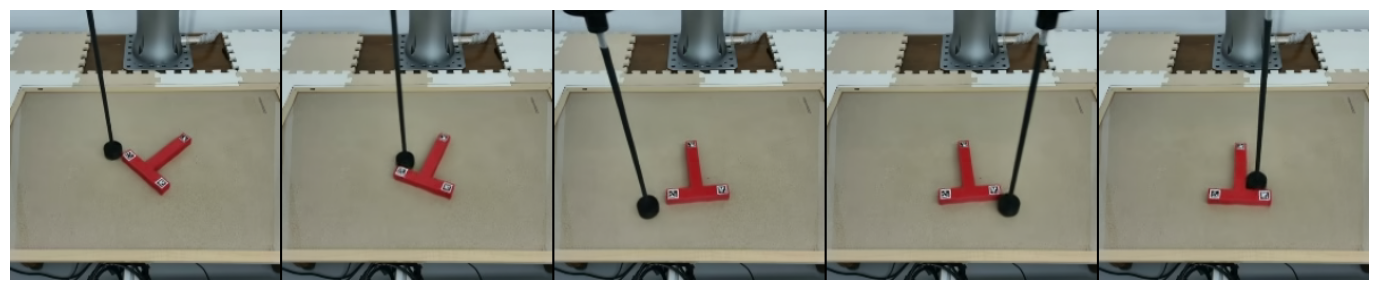

In [76]:
plotSnapshots(img_pred_pol[0].to(torch.float32))

In [78]:
plotActions(pr_act, title="Predicted future actions")

TypeError: plotActions() got an unexpected keyword argument 'title'

In [79]:
plotActions(gt_act, title="Ground-truth future actions")

TypeError: plotActions() got an unexpected keyword argument 'title'

## 4b. Action Sampler (`unified_action_sampler`)
Actions for **all** frames (context + horizon) start as pure noise and are jointly denoised. Obs are also denoised everywhere, but context obs starts at a user-chosen noise level (`ctx_obs_init_tau`) while horizon obs starts as pure noise. Each region runs its own Euler integration so it reaches the clean signal in `num_diffusion_steps` steps from its own starting tau.

In [105]:
latents_ctx_noisy.shape

torch.Size([1, 4, 256, 32])

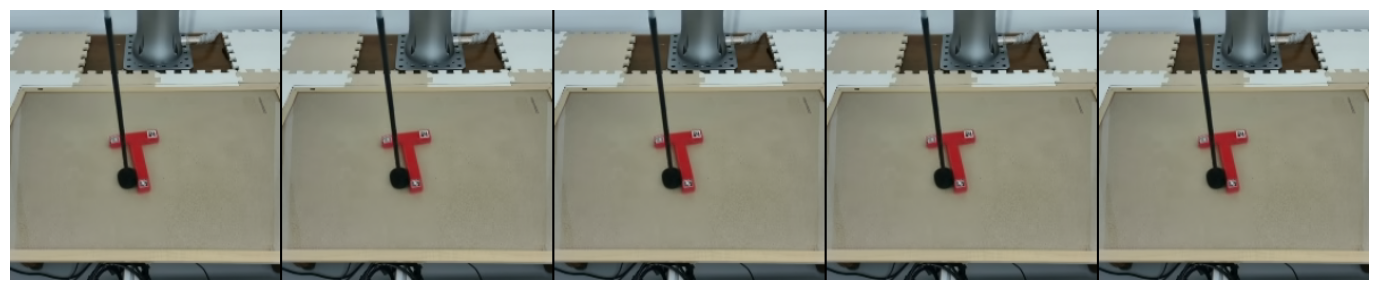

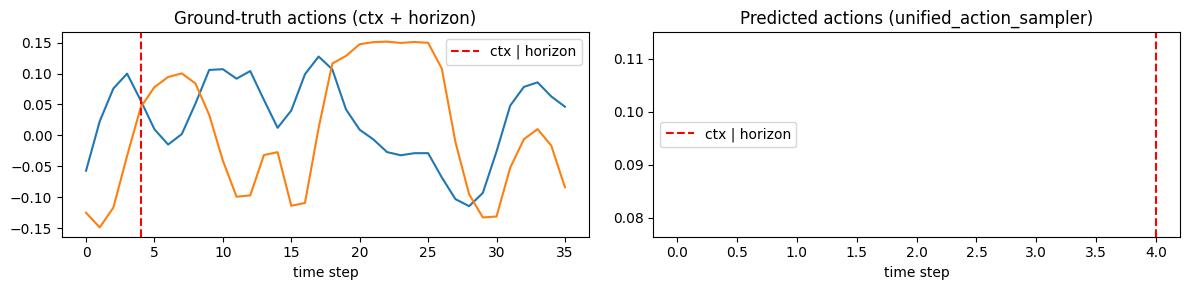

In [126]:
from dreamerv4uwm.sampling import unified_action_sampler

# ctx_obs_init_tau = 0.99  # noise level for context obs at start (0=pure noise, 1=clean)
# tau=0.99
latents_ctx_noisy = latents_ctx.clone()[:, :1, ...]


# # latents_ctx_noisy[:,1:] = (1-tau)*latents_ctx[:,1:] +torch.randn_like(latents_ctx[:,1:])*tau  # add noise to context obs for unified sampling
# latents_ctx_noisy = (1-tau)*latents_ctx +torch.randn_like(latents_ctx_noisy)*tau  # add noise to context obs for unified sampling
# ctx_actions_policy_noisy = (1-ctx_obs_init_tau) * torch.randn_like(ctx_actions_policy) + ctx_obs_init_tau * ctx_actions_policy

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_act, pred_act_act = unified_action_sampler(
        denoiser, torch.randn(1, 1, 256, 32).cuda(),
        ctx_actions=torch.randn(1, 1, 2).cuda(),  # only used to infer n_act
        num_pred_steps=0,
        num_diffusion_steps=8,
        ctx_obs_init_tau=0.0,
    )
    with torch.no_grad():
        img_pred_act = tokenizer.decode(pred_obs_act)

# Visualise the fully denoised obs sequence (context + horizon)
plotVideo(img_pred_act[0].to(torch.float32))
plotSnapshots(img_pred_act[0].to(torch.float32))




# Compare predicted vs ground-truth actions across the FULL sequence
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act_full = actions[:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act_full = pred_act_act[0].cpu().float().numpy()
axes[0].set_title("Ground-truth actions (ctx + horizon)")
axes[0].plot(gt_act_full)
axes[0].axvline(T_ctx, color='red', linestyle='--', label='ctx | horizon')
axes[0].legend()
axes[1].set_title("Predicted actions (unified_action_sampler)")
axes[1].plot(pr_act_full)
axes[1].axvline(T_ctx, color='red', linestyle='--', label='ctx | horizon')
axes[1].legend()
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

## 4c. Unified Video Sampler (`unified_video_sampler`)
Treats the entire sequence (context + horizon) as one unified noisy latent at a single `current_tau` and denoises every frame uniformly. Actions are pure noise throughout, with tau=0 conditioning fed to the denoiser — the model must reconstruct the video purely from the partially-noised visuals.

This browser does not support the video tag.


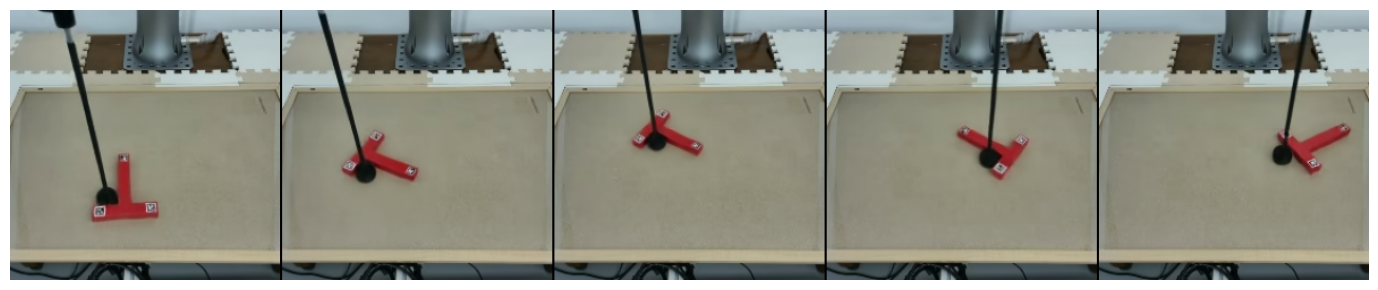

In [ ]:
from dreamerv4uwm.sampling import unified_video_sampler

num_diffusion_steps = 64
T_ctx = latents_ctx.shape[1]
T_total = 8

# Build a unified noisy latent: clean context + pure-noise horizon, then noise the whole thing to `current_tau`
l = torch.randn(1, T_total, *latents_ctx.shape[2:], device=latents_ctx.device, dtype=latents_ctx.dtype)
current_tau = 0.0  # starting noise level of the full (ctx + horizon) sequence

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_video = unified_video_sampler(
        denoiser,
        noisy_latents=l,
        current_tau=current_tau,
        n_act=cfg.denoiser.n_actions,
        num_diffusion_steps=num_diffusion_steps,
        use_shortcut=False,
    )
    with torch.no_grad():
        img_pred_video = tokenizer.decode(pred_obs_video)

plotVideo(img_pred_video[0].to(torch.float32))
plotSnapshots(img_pred_video[0].to(torch.float32))

## 5. Diffusion Forcing (`forcing`)
Given context obs + context actions (both conditioned with slight noise), jointly denoise future observations and actions. Both modalities are predicted for the future chunk.

This browser does not support the video tag.


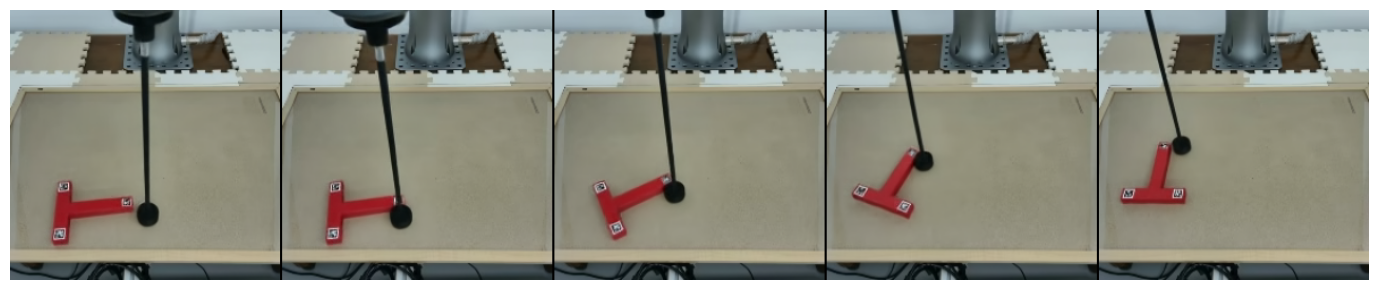

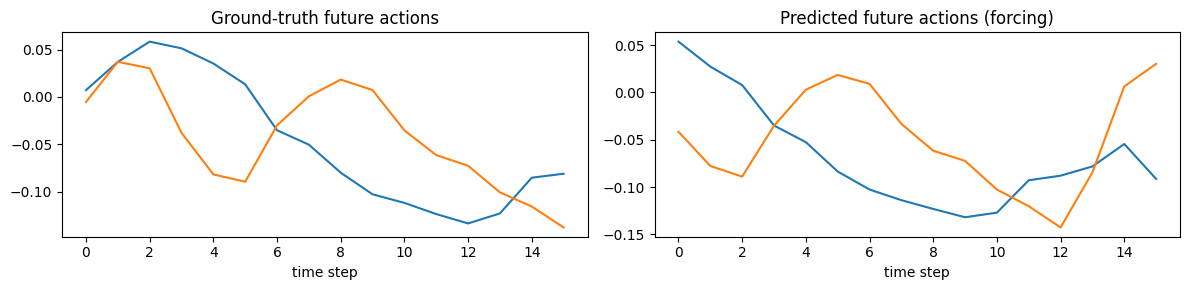

In [48]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_forc, pred_act_forc = unified_flowmatching_sampler(
        denoiser, latents_ctx, mode='forcing',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_forc = tokenizer.decode(pred_obs_forc)

plotVideo(img_pred_forc[0].to(torch.float32))
plotSnapshots(img_pred_forc[0].to(torch.float32))

# Plot predicted vs ground-truth actions
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_forc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (forcing)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()

# Unified Shortcut Sampler — All 5 UWM Modes

The samplers below target the **shortcut** UWM denoiser (trained with `compute_bootstrap_uwm_loss`). Unlike the flow-matching samplers, which always use the finest step (`step_idx = 0 ↔ d_min`), the shortcut samplers set `step_idx = get_step_index(1/num_diffusion_steps, num_noise_levels)` so the denoiser takes a big dyadic step per Euler update.

Make sure `dynamics_ckpt` points to a shortcut-trained checkpoint (see cell above:
`checkpoints/dynamics/pushT/with-shortcuts/...`).


In [14]:
from dreamerv4uwm.sampling import unified_shortcut_sampler

num_pred_steps = 16
num_diffusion_steps = 8   # power of two; shortcut big-step
latents_ctx = latents[:, :4, ...].clone()
T_ctx = latents_ctx.shape[1]


## 1. World Model (`wm`) — shortcut
Given context obs and **all** actions, predict future observations using the shortcut big-step sampler.

In [15]:
all_actions_wm = actions[:T_ctx + num_pred_steps][None].clone()
all_actions_wm[:, T_ctx:, 0] = 0.0
all_actions_wm[:, T_ctx:, 1] = 0.0

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_wm_sc, _ = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='wm',
        all_actions=all_actions_wm,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_wm_sc = tokenizer.decode(pred_obs_wm_sc)

plotVideo(img_pred_wm_sc[0].to(torch.float32))
plotSnapshots(img_pred_wm_sc[0].to(torch.float32), n_frames=4)
plotActions(all_actions_wm[0, T_ctx:T_ctx+num_pred_steps])


This browser does not support the video tag.


NameError: name 'plotSnapshots' is not defined

## 2. Policy (`policy`) — shortcut
Given context obs + context actions, jointly predict future observations and future actions.

In [16]:
ctx_actions_policy = actions[:T_ctx][None].cuda()

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_pol_sc, pred_act_pol_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='policy',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_pol_sc = tokenizer.decode(pred_obs_pol_sc)

plotVideo(img_pred_pol_sc[0].to(torch.float32))
plotSnapshots(img_pred_pol_sc[0].to(torch.float32))
plotActions(pred_act_pol_sc[0].cpu().float().numpy())


This browser does not support the video tag.


NameError: name 'plotSnapshots' is not defined

## 3. Video Prediction (`video`) — shortcut
Given context obs only (actions are pure noise), predict future observations.

In [ ]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_vid_sc, _ = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='video',
        ctx_actions=ctx_actions_policy,  # only used to infer n_act
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_vid_sc = tokenizer.decode(pred_obs_vid_sc)

plotVideo(img_pred_vid_sc[0].to(torch.float32))
plotSnapshots(img_pred_vid_sc[0].to(torch.float32))


## 4. Inverse Dynamics (`id`) — shortcut
Given **all** observations (clean), predict actions across all frames.

In [ ]:
all_latents_id = latents[:, :T_ctx + num_pred_steps, ...]

with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    _, pred_act_id_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='id',
        ctx_actions=ctx_actions_policy,
        all_latents=all_latents_id,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )

import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_id_sc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (inverse dynamics, shortcut)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()


## 5. Diffusion Forcing (`forcing`) — shortcut
Given context obs + context actions (both slightly noised), jointly denoise future obs and actions.

In [ ]:
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    pred_obs_forc_sc, pred_act_forc_sc = unified_shortcut_sampler(
        denoiser, latents_ctx, mode='forcing',
        ctx_actions=ctx_actions_policy,
        num_pred_steps=num_pred_steps,
        num_diffusion_steps=num_diffusion_steps,
    )
    with torch.no_grad():
        img_pred_forc_sc = tokenizer.decode(pred_obs_forc_sc)

plotVideo(img_pred_forc_sc[0].to(torch.float32))
plotSnapshots(img_pred_forc_sc[0].to(torch.float32))

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
gt_act = actions[T_ctx:T_ctx + num_pred_steps].cpu().float().numpy()
pr_act = pred_act_forc_sc[0].cpu().float().numpy()
axes[0].set_title("Ground-truth future actions")
axes[0].plot(gt_act)
axes[1].set_title("Predicted future actions (forcing, shortcut)")
axes[1].plot(pr_act)
for ax in axes:
    ax.set_xlabel("time step")
plt.tight_layout()
plt.show()


# Autoregressive Sampling — `AutoRegressiveForwardDynamics`

KV-cached, frame-by-frame rollout for the **flow-matching** UWM denoiser. The class wraps the denoiser and tokenizer together with their decoder caches and supports two modes:

- **`wm`** — world model. The caller passes the next action at every `step()`; the action is treated as clean and only the next observation is denoised.
- **`policy`** — `step()` takes no input; the next observation and the next action are denoised jointly. Context actions are slightly noised at `tau_cond` to match policy training.

Both modes prime the cache via `reset(imgs_init, actions_init)` and then advance one frame per `step()`.


In [19]:
from dreamerv4uwm.sampling import AutoRegressiveForwardDynamics
episode_length = 128
demo_end_index = 3
num_pred_steps = episode_length - demo_end_index
T_ctx = demo_end_index

denoising_step_count = 16        # power of two; flow-matching Euler steps per frame
context_cond_tau = 0.99
# max_forward_steps = T_ctx + num_pred_steps + 4   # safety margin for KV cache size
max_forward_steps = 64   # safety margin for KV cache size

imgs_ctx = imgs[:, :T_ctx]                      # (1, T_ctx, C, H, W)
actions_ctx = actions[:T_ctx][None].to(device)  # (1, T_ctx, n_act)

N_batch = 4
imgs_ctx = imgs_ctx.expand(N_batch, -1, -1, -1, -1)
actions_ctx = actions_ctx.expand(N_batch, -1, -1)

## 1. World-model rollout (`mode='wm'`)
We supply the next action at every step — actions are treated as clean and only the next obs is denoised. We feed the ground-truth future actions for the visualisation.


In [20]:
ar_wm = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='wm',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)

future_actions_wm = torch.zeros(1, num_pred_steps, actions_ctx.shape[-1], device=device)  # (1, T_pred, n_act)
future_actions_wm = future_actions_wm * 0.0   # zero-action rollout for visualisation
future_actions_wm[:, :, 0] = -0.00
future_actions_wm[:, :, 1] = 0.0
frames_wm = []
with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
    ar_wm.reset(imgs_ctx, actions_ctx)
    for t in range(num_pred_steps):
        img_t = ar_wm.step(actions_t=future_actions_wm[:, t])
        frames_wm.append(img_t.detach().cpu())

video_wm = torch.stack(frames_wm, dim=1)[0]      # (num_pred_steps, C, H, W)
plotVideo(video_wm.to(torch.float32))
plotSnapshots(video_wm.to(torch.float32), n_frames=5)
plotActions(future_actions_wm[0])


RuntimeError: Sizes of tensors must match except in dimension 2. Expected size 4 but got size 1 for tensor number 4 in the list.

## 2. Policy rollout (`mode='policy'`)
No actions are fed during rollout — the policy denoises the next obs and the next action jointly at each step.


In [21]:
ar_pol = AutoRegressiveForwardDynamics(
    denoiser=denoiser,
    tokenizer=tokenizer,
    mode='policy',
    context_length=max_forward_steps,
    max_forward_steps=max_forward_steps,
    context_cond_tau=context_cond_tau,
    denoising_step_count=denoising_step_count,
    device=device,
    dtype=torch.float32,
)



In [22]:
frames_pol, acts_pol = [], []
with torch.no_grad():
    with torch.autocast(device_type='cuda', dtype=torch.bfloat16):
        ar_pol.reset(imgs_ctx, actions_ctx)
        for t in range(num_pred_steps):
            img_t, act_t = ar_pol.step()
            frames_pol.append(img_t.detach().cpu())
            acts_pol.append(act_t.detach().cpu())

In [23]:
video_pol = torch.stack(frames_pol, dim=1)
acts_pol_seq = torch.stack(acts_pol, dim=1)

video_all = torch.concat([imgs[:, :T_ctx].cpu().expand(video_pol.shape[0], -1, -1, -1, -1), video_pol.cpu()], dim=1)  # (1, 3, T, C, H, W)
# actions_all = torch.concat([actions[:T_ctx].cpu(), acts_pol_seq.cpu()], dim=0)  # (1, T, n_act)
for k in range(video_all.shape[0]):
    plotVideo(video_all.to(torch.float32)[k])

# plotSnapshots(video_all.to(torch.float32), n_frames=5)
# plotActions(acts_pol_seq.to(torch.float32))

This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.


This browser does not support the video tag.
